In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import requests
from ira.ingest.ingest_scorecard import save
from ira.clean.clean_scorecard import clean
from ira.config import SCORECARD_KEY, BASE_URL
import math
import json
import time

root = Path.cwd()/'institutional-roi-analysis'
# os.chdir(root/"Seb_branch"/"institutional-roi-analysis"/"notebooks")
pd.set_option("display.max_columns",None)
display(root)

WindowsPath('C:/Users/sebas/PycharmProjects/Git/Seb_branch/institutional-roi-analysis')

In [432]:
residual_df = pd.read_csv(root/"data"/"raw"/"scorecard"/"raw_residual_FL_stable_programs.csv")
ipedsd_df = pd.read_csv(root/"data"/"clean"/"ipeds"/"clean_ipeds_drivers.csv")

In [433]:
residual_df.head()

,code,credential_level,unit_id,distance,school_type,5_yr_working_count,location_lat,location_lon,locale,carnegie_size_setting,admission_rate_overall,median_family_income,students_with_pell_grant,open_admissions_policy,age_entry,title_iv_eligibility_type,selectivity_bucket,5_year_earning_log,5_year_pred_log,title,school_name,5_year_earning,5_year_pred,5_year_error,4_year_earning,4_year_earning_log,4_year_pred,4_year_pred_log,4_year_error,4_yr_working_count,1_year_earning,1_year_earning_log,1_year_pred,1_year_pred_log,1_year_error,1_yr_working_count,school_count,confidence,1_year_pct_error,1_year_score,4_year_pct_error,4_year_score,5_year_pct_error,5_year_score,rank_1,rank_4,rank_5,move_1_to_4,move_4_to_5,move_1_to_5,rank_std,rank_std_pct,mean_rank_std_pct,median_score
0,301,3,133492,1,"Private, nonprofit",56.0,27.715798,-82.687043,11,11,0.7580,77695.0,0.411392,2.0,21.0,1,open,10.662914,10.643175,Natural Resources Conservation and Research.,Eckerd College,42741.0,41905.617,835.382813,39932.0,10.594933,50566.960,10.831054,-10634.960938,77,25709.0,10.154596,29107.588,10.278754,-3398.587891,94.0,8,medium,-0.116760,-0.115420,-0.210314,-0.207225,0.019935,0.019527,6.0,8.0,3.0,2.0,-5.0,-3.0,2.516611,0.359516,0.250313,-0.115420
1,301,3,133951,2,Public,36.0,25.757320,-80.373928,21,15,0.5466,23924.0,0.813127,2.0,23.0,1,mid,10.745076,10.783957,Natural Resources Conservation and Research.,Florida International University,46401.0,48240.610,-1839.609375,49748.0,10.814726,55158.484,10.917966,-5410.484375,24,36007.0,10.491469,33721.535,10.425892,2285.464844,21.0,8,medium,0.067775,0.063452,-0.098090,-0.092620,-0.038134,-0.036835,2.0,7.0,6.0,5.0,-1.0,4.0,2.645751,0.377964,0.250313,-0.036835
2,301,3,134097,1,Public,78.0,30.443147,-84.295064,12,15,0.2422,43729.0,0.597532,2.0,20.0,1,elite,10.780705,10.786012,Natural Resources Conservation and Research.,Florida State University,48084.0,48339.850,-255.851562,54288.0,10.902058,52498.200,10.868534,1789.800781,188,30146.0,10.313808,36875.710,10.515308,-6729.710937,161.0,8,medium,-0.182497,-0.181380,0.034093,0.033916,-0.005293,-0.005219,7.0,5.0,5.0,-2.0,0.0,-2.0,1.154701,0.164957,0.250313,-0.005219
3,301,3,134130,1,Public,28.0,29.646290,-82.347911,12,16,0.2420,39127.0,0.667383,2.0,21.0,1,elite,10.895108,10.878085,Natural Resources Conservation and Research.,University of Florida,53912.0,53002.010,909.988281,62683.0,11.045846,57587.316,10.961058,5095.683594,29,34454.0,10.447380,36076.906,10.493408,-1622.906250,29.0,8,medium,-0.044985,-0.042980,0.088486,0.084491,0.017169,0.016391,5.0,3.0,4.0,-2.0,1.0,-1.0,1.000000,0.142857,0.250313,0.016391
4,301,3,136950,1,"Private, nonprofit",29.0,28.592787,-81.349239,21,11,0.4754,43978.0,0.580000,2.0,22.0,1,mid,10.517050,10.832608,Natural Resources Conservation and Research.,Rollins College,36940.0,50645.630,-13705.628906,63363.0,11.056635,52899.145,10.876143,10463.855469,23,22352.0,10.014671,34313.710,10.443300,-11961.710937,18.0,8,medium,-0.348599,-0.322316,0.197808,0.186247,-0.270618,-0.258835,8.0,2.0,8.0,-6.0,6.0,0.0,3.464102,0.494872,0.250313,-0.258835


In [434]:
# Do the year errors generally agree in direction?
residual_df['sign_agreement'] = (
    np.sign(residual_df['1_year_error']) == 
    np.sign(residual_df['4_year_error'])
) & (
    np.sign(residual_df['4_year_error']) == 
    np.sign(residual_df['5_year_error'])
)

print(residual_df['sign_agreement'].value_counts(normalize=True))

# Also check correlation between year errors
print(residual_df[['1_year_error','4_year_error','5_year_error']].corr())

False    0.572056
True     0.427944
Name: sign_agreement, dtype: float64
              1_year_error  4_year_error  5_year_error
1_year_error      1.000000      0.593404      0.407938
4_year_error      0.593404      1.000000      0.524356
5_year_error      0.407938      0.524356      1.000000


to avoid canceled signals

In [458]:
residual_df['total_pred'] = residual_df[
    ["1_year_pred", "4_year_pred", "5_year_pred"]
].sum(axis=1)

residual_df["total_count"] = (
    residual_df["1_yr_working_count"] +
    residual_df["4_yr_working_count"] +
    residual_df["5_yr_working_count"]
)

k = np.percentile(np.log1p(residual_df["total_count"]), 75)

residual_df["weight"] = (
    np.log1p(residual_df["total_count"]) /
    np.log1p(residual_df["total_count"] + k)
)

residual_df["combined_pct_error"] = residual_df[
    ["1_year_error", "4_year_error", "5_year_error"]
].median(axis=1) / residual_df['total_pred'] * 3

consistent_mask = residual_df['sign_agreement'] == True
residual_df = residual_df[consistent_mask]
print(f"Consistent schools: {consistent_mask.sum()} of {len(residual_df)}")

residual_df

Consistent schools: 585 of 585


,code,credential_level,unit_id,distance,school_type,5_yr_working_count,location_lat,location_lon,locale,carnegie_size_setting,admission_rate_overall,median_family_income,students_with_pell_grant,open_admissions_policy,age_entry,title_iv_eligibility_type,selectivity_bucket,5_year_earning_log,5_year_pred_log,title,school_name,5_year_earning,5_year_pred,5_year_error,4_year_earning,4_year_earning_log,4_year_pred,4_year_pred_log,4_year_error,4_yr_working_count,1_year_earning,1_year_earning_log,1_year_pred,1_year_pred_log,1_year_error,1_yr_working_count,school_count,confidence,1_year_pct_error,1_year_score,4_year_pct_error,4_year_score,5_year_pct_error,5_year_score,rank_1,rank_4,rank_5,move_1_to_4,move_4_to_5,move_1_to_5,rank_std,rank_std_pct,mean_rank_std_pct,median_score,sign_agreement,total_pred,total_count,weight,combined_pct_error
6,301,3,138354,2,Public,21.0,30.549076,-87.218511,41,12,0.5824,34583.0,0.678606,2.0,24.0,1,mid,10.838620,10.595456,Natural Resources Conservation and Research.,University of West Florida,50951.0,39952.883,10998.117187,50746.0,10.834588,42149.586,10.648980,8596.414063,16,37214.0,10.524440,32908.348,10.401482,4305.652344,20.0,8,medium,0.130838,0.122037,0.203950,0.186301,0.275277,0.258103,1.0,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.250313,0.186301,True,115010.817,57.0,0.975388,0.224233
8,402,3,133669,0,Public,54.0,26.372421,-80.102978,13,15,0.6613,28064.0,0.721905,2.0,23.0,1,mid,11.073117,10.899892,Architecture.,Florida Atlantic University,64416.0,54170.504,10245.496094,64730.0,11.077980,57778.320,10.964369,6951.679687,49,46551.0,10.748304,38668.310,10.562776,7882.691406,44.0,3,low,0.203854,0.198206,0.120316,0.117331,0.189134,0.185097,2.0,1.0,1.0,-1.0,0.0,-1.0,0.577350,0.115470,0.076980,0.185097,True,150617.134,147.0,0.991781,0.157008
11,402,5,133951,0,Public,128.0,25.757320,-80.373928,21,15,0.5466,23924.0,0.813127,2.0,23.0,1,mid,11.116589,11.239933,Architecture.,Florida International University,67278.0,76109.850,-8831.851562,68932.0,11.140876,79349.560,11.281618,-10417.562500,119,47559.0,10.769726,59970.094,11.001601,-12411.093750,140.0,3,low,-0.206955,-0.205464,-0.131287,-0.130127,-0.116041,-0.115136,3.0,3.0,2.0,0.0,-1.0,-1.0,0.577350,0.115470,0.153960,-0.130127,True,215429.504,387.0,0.997323,-0.145072
13,402,5,137351,1,Public,65.0,28.061458,-82.413232,11,15,0.4319,32495.0,0.685900,2.0,22.0,1,mid,11.096773,11.199785,Architecture.,University of South Florida,65958.0,73114.734,-7156.734375,70924.0,11.169364,75764.270,11.235382,-4840.273437,50,49537.0,10.810475,55705.840,10.927840,-6168.839844,42.0,3,low,-0.110740,-0.107503,-0.063886,-0.062337,-0.097884,-0.096199,2.0,2.0,1.0,0.0,-1.0,-1.0,0.577350,0.115470,0.153960,-0.096199,True,204584.844,157.0,0.992386,-0.090459
15,901,3,133492,1,"Private, nonprofit",26.0,27.715798,-82.687043,11,11,0.7580,77695.0,0.411392,2.0,21.0,1,open,10.856669,10.652192,Communication and Media Studies.,Eckerd College,51879.0,42285.188,9593.812500,60969.0,11.018121,47938.293,10.777670,13030.707031,22,33544.0,10.420613,29060.910,10.277149,4483.089844,22.0,13,medium,0.154265,0.144917,0.271823,0.255139,0.226884,0.215715,1.0,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.240839,0.215715,True,119284.391,70.0,0.980570,0.241284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1349,5214,3,134130,1,Public,189.0,29.646290,-82.347911,12,16,0.2420,39127.0,0.667383,2.0,21.0,1,elite,11.297663,11.196403,Marketing.,University of Florida,80633.0,72867.836,7765.164063,92626.0,11.436325,76833.670,11.249398,15792.328125,184,56454.0,10.941181,46053.250,10.737554,10400.750000,165.0,14,medium,0.225842,0.224498,0.205539,0.204447,0.106565,0.106038,1.0,1.0,4.0,0.0,3.0,3.0,1.732051,0.133235,0.187422,0.204447,True,195754.756,538.0,0.998168,0.159395
1351,5214,3,135726,1,"Private, nonprofit",48.0,25.721260,-80.278662,21,16,0.1890,5

In [459]:
ipedsd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6909 entries, 0 to 6908
Data columns (total 27 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   unit_id                                   6909 non-null   int64  
 1   year                                      6909 non-null   int64  
 2   code                                      6909 non-null   int64  
 3   credential_level                          6909 non-null   int64  
 4   program_completers                        6909 non-null   int64  
 5   program_completers_log                    6909 non-null   float64
 6   program_completer_share_within_school     6906 non-null   float64
 7   no_ap_credit                              6909 non-null   float64
 8   study_abroad                              6909 non-null   float64
 9   career_counseling                         6909 non-null   float64
 10  employment_services                 

In [460]:
ipedsd_df=ipedsd_df.drop(columns=['instruction_salary_pct', 'academic_support_salary_pct',
       'student_services_salary_pct', 'research_salary_pct'])

KeyError: "['instruction_salary_pct', 'academic_support_salary_pct', 'student_services_salary_pct', 'research_salary_pct'] not found in axis"

In [ ]:
ipedsd_df.head()

,unit_id,year,code,credential_level,program_completers,program_completers_log,program_completer_share_within_school,no_ap_credit,study_abroad,career_counseling,employment_services,placement_services,instruction_expense_pct,research_expense_pct,student_service_expense_pct,endowment_per_fte,equity_ratio,staff_per_student,instructional_fte_per_student,irps_fte_per_student,instructional_share_of_staff,research_share_of_staff,instructional_staff_total,instructional_staff_short_contract,instructional_staff_long_contract,instructional_staff_long_contract_share,instructional_staff_short_contract_share
0,132374,2020,1101,1,14,2.708050,0.016588,0.0,0.0,1.0,0.0,1.0,71.0,0.0,5.0,NaN,NaN,0.096838,0.057065,0.057065,0.589286,0.0,0.0,0.0,0.0,NaN,NaN
1,132374,2020,1102,1,10,2.397895,0.011848,0.0,0.0,1.0,0.0,1.0,71.0,0.0,5.0,NaN,NaN,0.096838,0.057065,0.057065,0.589286,0.0,0.0,0.0,0.0,NaN,NaN
2,132374,2020,1108,1,40,3.713572,0.047393,0.0,0.0,1.0,0.0,1.0,71.0,0.0,5.0,NaN,NaN,0.096838,0.057065,0.057065,0.589286,0.0,0.0,0.0,0.0,NaN,NaN
3,132374,2020,1109,1,34,3.555348,0.040284,0.0,0.0,1.0,0.0,1.0,71.0,0.0,5.0,NaN,NaN,0.096838,0.057065,0.057065,0.589286,0.0,0.0,0.0,0.0,NaN,NaN
4,132374,2020,1205,1,47,3.871201,0.055687,0.0,0.0,1.0,0.0,1.0,71.0,0.0,5.0,NaN,NaN,0.096838,0.057065,0.057065,0.589286,0.0,0.0,0.0,0.0,NaN,NaN


In [461]:
targ='combined_pct_error'
merge_df=ipedsd_df.merge(residual_df[["unit_id","code","credential_level","school_name",targ,'weight']], on = ["unit_id","code","credential_level"], how="right")

In [462]:
model_df=merge_df.copy()
print("ipedsd_df shape:", ipedsd_df.shape)
print("residual_df shape:", residual_df.shape)
print("model_df shape:", model_df.shape)

print("model_df columns:")
print(sorted(model_df.columns.tolist()))

ipedsd_df shape: (6909, 27)
residual_df shape: (585, 59)
model_df shape: (585, 30)
model_df columns:
['career_counseling', 'code', 'combined_pct_error', 'credential_level', 'employment_services', 'endowment_per_fte', 'equity_ratio', 'instruction_expense_pct', 'instructional_fte_per_student', 'instructional_share_of_staff', 'instructional_staff_long_contract', 'instructional_staff_long_contract_share', 'instructional_staff_short_contract', 'instructional_staff_short_contract_share', 'instructional_staff_total', 'irps_fte_per_student', 'no_ap_credit', 'placement_services', 'program_completer_share_within_school', 'program_completers', 'program_completers_log', 'research_expense_pct', 'research_share_of_staff', 'school_name', 'staff_per_student', 'student_service_expense_pct', 'study_abroad', 'unit_id', 'weight', 'year']


In [463]:
model_df=model_df.drop(columns=[
    'year',
    # 'program_completer_share_within_school','program_completers',
    # 'program_completers_log',"credential_level",
    'code',
    # 'unit_id',
    # 'school_name'
    ]
)

In [464]:
inst_model_df=model_df.copy()

In [465]:
display(inst_model_df.describe())
display("Feature correlation to target variable",inst_model_df.corr()[targ].sort_values())
display(inst_model_df.info())

# drop_cols=[
#     "instruction_expense_pct",
#     "student_service_expense_pct",
#     "career_counseling",
#     "employment_services",
# ]

,unit_id,credential_level,program_completers,program_completers_log,program_completer_share_within_school,no_ap_credit,study_abroad,career_counseling,employment_services,placement_services,instruction_expense_pct,research_expense_pct,student_service_expense_pct,endowment_per_fte,equity_ratio,staff_per_student,instructional_fte_per_student,irps_fte_per_student,instructional_share_of_staff,research_share_of_staff,instructional_staff_total,instructional_staff_short_contract,instructional_staff_long_contract,instructional_staff_long_contract_share,instructional_staff_short_contract_share,combined_pct_error,weight
count,585.000000,585.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,332.000000,332.000000,332.000000,307.000000,315.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,510.000000,510.000000,585.000000,585.000000
mean,204921.100855,3.005128,155.647687,4.248570,0.091017,0.092527,0.729537,0.991103,0.944840,0.944840,35.855422,11.012048,7.111446,11110.335505,55.955556,0.112989,0.034958,0.040696,0.361988,0.016798,1404.252669,3.793594,1400.459075,0.995294,0.004706,0.016624,0.992997
std,130551.857722,1.346599,429.469818,1.230475,0.205463,0.290026,0.444595,0.093986,0.228496,0.228496,8.920776,9.368578,4.084780,11408.807991,14.738417,0.093814,0.018582,0.026810,0.115366,0.022068,1496.685565,28.208798,1497.171421,0.027983,0.027983,0.166283,0.006297
min,132471.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,0.000000,0.000000,227.000000,37.000000,0.016738,0.007823,0.007823,0.131088,0.000000,0.000000,0.000000,0.000000,0.750000,0.000000,-0.510359,0.972659
25%,133951.000000,2.000000,33.250000,3.533607,0.006873,0.000000,0.000000,1.000000,1.000000,1.000000,30.000000,0.000000,5.000000,2659.000000,43.000000,0.055134,0.021904,0.022601,0.292579,0.000000,196.500000,0.000000,196.500000,1.000000,0.000000,-0.100072,0.989984
50%,136172.000000,3.000000,69.500000,4.255588,0.016616,0.000000,1.000000,1.000000,1.000000,1.000000,36.000000,13.000000,5.000000,6758.000000,57.000000,0.083664,0.032074,0.032123,0.338129,0.000000,686.000000,0.000000,686.000000,1.000000,0.000000,-0.001499,0.994881
75%,138354.000000,3.000000,137.750000,4.932669,0.051603,0.000000,1.000000,1.000000,1.000000,1.000000,38.000000,17.000000,10.000000,12079.000000,69.000000,0.143447,0.046742,0.046742,0.427624,0.040203,2636.000000,0.000000,2636.000000,1.000000,0.000000,0.124961,0.998012
max,499495.000000,7.000000,7122.000000,8.871084,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,73.000000,25.000000,17.000000,55596.000000,89.000000,0.590156,0.152610,0.152610,0.723684,0.063864,5044.000000,238.000000,5044.000000,1.000000,0.250000,0.947358,0.999975


C:\Users\sebas\AppData\Local\Temp\ipykernel_25708\2618554094.py:2: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



'Feature correlation to target variable'

equity_ratio                               -0.057071
placement_services                         -0.031864
student_service_expense_pct                -0.028165
staff_per_student                          -0.020289
unit_id                                    -0.020233
career_counseling                          -0.019432
research_expense_pct                       -0.018787
no_ap_credit                               -0.018384
research_share_of_staff                    -0.016348
program_completers                         -0.013778
instructional_staff_long_contract_share    -0.011270
program_completers_log                     -0.007747
weight                                     -0.005612
irps_fte_per_student                        0.001539
instructional_fte_per_student               0.003238
instructional_share_of_staff                0.004587
instructional_staff_short_contract_share    0.011270
endowment_per_fte                           0.011655
instruction_expense_pct                     0.

<class 'pandas.core.frame.DataFrame'>
Int64Index: 585 entries, 0 to 584
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   unit_id                                   585 non-null    int64  
 1   credential_level                          585 non-null    int64  
 2   program_completers                        562 non-null    float64
 3   program_completers_log                    562 non-null    float64
 4   program_completer_share_within_school     562 non-null    float64
 5   no_ap_credit                              562 non-null    float64
 6   study_abroad                              562 non-null    float64
 7   career_counseling                         562 non-null    float64
 8   employment_services                       562 non-null    float64
 9   placement_services                        562 non-null    float64
 10  instruction_expense_pct               

None

In [466]:
import plotly.express as px
px.histogram(inst_model_df[targ])

In [467]:
len(inst_model_df[targ])

585

In [468]:
inst_model_df[targ].skew()

0.6179348837935233

In [469]:
inst_model_df[targ].describe()

count    585.000000
mean       0.016624
std        0.166283
min       -0.510359
25%       -0.100072
50%       -0.001499
75%        0.124961
max        0.947358
Name: combined_pct_error, dtype: float64

In [472]:
def build_target_variants(df):
    d = df.copy()
    
    # raw errors
    e1 = d["1_year_error"]
    e4 = d["4_year_error"]
    e5 = d["5_year_error"]
    
    # counts
    c1 = d["1_yr_working_count"]
    c4 = d["4_yr_working_count"]
    c5 = d["5_yr_working_count"]
    total_count = d["total_count"]
    total_pred  = d["total_pred"]
    
    targets = {}

    # --- pct error variants ---
    targets["pct_sum_over_pred"] = (e1 + e4 + e5) / total_pred

    targets["pct_mean_over_pred"] = (
        (e1/total_pred + e4/total_pred + e5/total_pred) / 3
    )

    targets["pct_count_weighted"] = (
        e1*c1 + e4*c4 + e5*c5
    ) / (total_count * total_pred)

    targets["pct_median_year"] = (
        pd.concat([e1/total_pred, e4/total_pred, e5/total_pred], axis=1)
        .median(axis=1)
    )

    # --- log scale variants ---
    targets["log_error_sum"] = (
        d["1_year_earning_log"] - d["1_year_pred_log"] +
        d["4_year_earning_log"] - d["4_year_pred_log"] +
        d["5_year_earning_log"] - d["5_year_pred_log"]
    )

    targets["log_error_mean"] = targets["log_error_sum"] / 3

    targets["log_error_count_weighted"] = (
        (d["1_year_earning_log"] - d["1_year_pred_log"]) * c1 +
        (d["4_year_earning_log"] - d["4_year_pred_log"]) * c4 +
        (d["5_year_earning_log"] - d["5_year_pred_log"]) * c5
    ) / total_count

    # --- sign-consistent only (mask applied later) ---
    targets["pct_sum_sign_consistent"] = targets["pct_sum_over_pred"].copy()
    sign_mask = (
        (np.sign(e1) == np.sign(e4)) & (np.sign(e4) == np.sign(e5))
    )
    targets["pct_sum_sign_consistent"][~sign_mask] = np.nan

    return targets, sign_mask


def run_target_screen(merge_df, feature_cols, target_variants, sign_mask, weight_col="weight"):
    
    results = []
    
    for name, target_series in target_variants.items():
        
        # align and drop nulls
        df_tmp = merge_df[feature_cols + [weight_col]].copy()
        df_tmp["__target__"] = target_series.values
        df_tmp = df_tmp.dropna(subset=["__target__"])
        df_tmp = df_tmp.dropna(subset=feature_cols)
        
        if len(df_tmp) < 50:
            print(f"Skipping {name} — too few rows ({len(df_tmp)})")
            continue
        
        X = df_tmp[feature_cols]
        y = df_tmp["__target__"]
        w = df_tmp[weight_col]
        
        # winsorize target to reduce outlier noise
        lo, hi = y.quantile(0.02), y.quantile(0.98)
        y = y.clip(lo, hi)
        
        # top correlations
        corr = X.corrwith(y).abs().sort_values(ascending=False)
        top_corr = corr.iloc[0]
        top_feat = corr.index[0]
        mean_corr = corr.mean()
        
        # RF R² via cross-val with sample weights
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        
        try:
            cv_scores = cross_val_score(
                rf, X, y,
                cv=5,
                scoring="r2",
                fit_params={"sample_weight": w}  # note: use custom CV if this errors
            )
            rf_r2 = cv_scores.mean()
        except Exception:
            rf_r2 = np.nan
        
        results.append({
            "target":        name,
            "n_rows":        len(df_tmp),
            "top_corr_feat": top_feat,
            "top_corr":      round(top_corr, 4),
            "mean_abs_corr": round(mean_corr, 4),
            "rf_cv_r2":      round(rf_r2, 4) if not np.nan else rf_r2,
        })
        
        print(f"✓ {name:40s} | n={len(df_tmp):4d} | top_corr={top_corr:.3f} ({top_feat}) | RF R²={rf_r2:.3f}")
    
    return pd.DataFrame(results).sort_values("rf_cv_r2", ascending=False)

# ── RUN IT ───────────────────────────────────────────────────────
target_variants, sign_mask = build_target_variants(residual_df)

feature_cols = [c for c in merge_df.columns if c in inst_model_df.columns 
                and c not in ["unit_id", "code", "credential_level", 
                               "school_name", "weight", "avg_rank_stability",'combined_pct_error']]

results_df = run_target_screen(merge_df, feature_cols, target_variants, sign_mask)
print("\n", results_df)

✓ pct_sum_over_pred                        | n= 307 | top_corr=0.096 (study_abroad) | RF R²=-0.646
✓ pct_mean_over_pred                       | n= 307 | top_corr=0.096 (study_abroad) | RF R²=-0.636
✓ pct_count_weighted                       | n= 307 | top_corr=0.093 (study_abroad) | RF R²=-0.632
✓ pct_median_year                          | n= 307 | top_corr=0.096 (study_abroad) | RF R²=-0.637
✓ log_error_sum                            | n= 307 | top_corr=0.094 (study_abroad) | RF R²=-0.659
✓ log_error_mean                           | n= 307 | top_corr=0.094 (study_abroad) | RF R²=-0.654
✓ log_error_count_weighted                 | n= 307 | top_corr=0.088 (study_abroad) | RF R²=-0.633
✓ pct_sum_sign_consistent                  | n= 307 | top_corr=0.096 (study_abroad) | RF R²=-0.646

                      target  n_rows top_corr_feat  top_corr  mean_abs_corr  \
2        pct_count_weighted     307  study_abroad    0.0933         0.0281   
6  log_error_count_weighted     307  study_abroad 

In [470]:
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, StratifiedKFold
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42

In [ ]:
# -------------------
# 1. Define target
# -------------------

# Drop target and target-like columns from X
feature_cols = [c for c in inst_model_df.columns if c not in ["unit_id", targ, "weight",'credential_level','code','avg_rank_stability']]

X = inst_model_df[feature_cols]

y = np.log1p(inst_model_df[targ].abs())
# y = y.clip(upper=y.quantile(0.9))

w = inst_model_df["weight"]

# Force predictors numeric
X = X.apply(pd.to_numeric, errors="coerce")

# -------------------
# 2. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=RANDOM_STATE
)

# -------------------
# 4. Recompute numeric columns
# -------------------
num_cols = X_train.columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols)
])

In [450]:
len(y)

1367

In [455]:
X.columns

Index(['program_completers', 'program_completers_log',
       'program_completer_share_within_school', 'no_ap_credit', 'study_abroad',
       'career_counseling', 'employment_services', 'placement_services',
       'instruction_expense_pct', 'research_expense_pct',
       'student_service_expense_pct', 'endowment_per_fte', 'equity_ratio',
       'staff_per_student', 'instructional_fte_per_student',
       'irps_fte_per_student', 'instructional_share_of_staff',
       'research_share_of_staff', 'instructional_staff_total',
       'instructional_staff_short_contract',
       'instructional_staff_long_contract',
       'instructional_staff_long_contract_share',
       'instructional_staff_short_contract_share', 'school_name'],
      dtype='object')

In [327]:
# -------------------
# 5. Ridge model
# -------------------
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", Ridge())
])

# ridge_model = TransformedTargetRegressor(
#     regressor=ridge_pipe,
#     transformer=PowerTransformer(method="yeo-johnson", standardize=False)
# )

ridge_param_grid = {
    "reg__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 50.0, 100.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

ridge_grid.fit(
    X_train,
    y_train,
    reg__sample_weight=w_train
)

ridge_best = ridge_grid.best_estimator_
ridge_preds = ridge_best.predict(X_test)

print("RIDGE")
print("Best params:", ridge_grid.best_params_)
print("Best CV MAE:", round(-ridge_grid.best_score_, 4))
print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, ridge_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, ridge_preds), 4))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
RIDGE
Best params: {'reg__alpha': 100.0}
Best CV MAE: 0.0553
Test MAE (vs unclipped y_test): 0.0559
Test R2 (vs unclipped y_test): -0.0804


In [328]:
enet_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", ElasticNet(max_iter=100000))
])

# enet_model = TransformedTargetRegressor(
#     regressor=enet_pipe,
#     transformer=PowerTransformer(method="yeo-johnson", standardize=False)
# )

enet_param_grid = {
    "reg__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 50.0],
    "reg__l1_ratio": [0.005,0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_grid = GridSearchCV(
    estimator=enet_pipe,
    param_grid=enet_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

enet_grid.fit(
    X_train, 
    y_train,
    reg__sample_weight=w_train
)

enet_best = enet_grid.best_estimator_
enet_preds = enet_best.predict(X_test)

print("\nELASTIC NET")
print("Best params:", enet_grid.best_params_)
print("Best CV MAE:", round(-enet_grid.best_score_, 4))
print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, enet_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, enet_preds), 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits

ELASTIC NET
Best params: {'reg__alpha': 0.01, 'reg__l1_ratio': 0.3}
Best CV MAE: 0.0551
Test MAE (vs unclipped y_test): 0.0556
Test R2 (vs unclipped y_test): -0.0364


In [329]:
y_pred = [y.mean()] * len(y)

mean_absolute_error(y, y_pred)

0.056229701012845114

In [330]:
from sklearn.ensemble import HistGradientBoostingRegressor

def run_hgbr():
    hgbr_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
    ])
    

    hgbr_model.fit(
        X_train, 
        y_train,
        model__sample_weight=w_train
    ) 
    preds = hgbr_model.predict(X_test) 
    print("MAE:", mean_absolute_error(y_test, preds)) 
    print("R2:", r2_score(y_test, preds))
run_hgbr()

MAE: 0.05476606785855105
R2: -0.053368136206315864


In [331]:
def run_hgbr_2():
    hgbr_model_2 = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor(
        max_depth=5,              # allow more interactions
        learning_rate=0.01,       # slower learning
        max_iter=750,             # more trees
        min_samples_leaf=10,      # regularization
        l2_regularization=2.0,    # stabilize
        random_state=42
        ))
    ])
  

    hgbr_model_2.fit(
        X_train, 
        y_train,
        model__sample_weight=w_train
    ) 

    preds_2 = hgbr_model_2.predict(X_test) 
    print("MAE:", mean_absolute_error(y_test, preds_2)) 
    print("R2:", r2_score(y_test, preds_2))
run_hgbr_2()

MAE: 0.05653968718982104
R2: -0.11346217655219903


In [332]:
from sklearn.model_selection import cross_val_score

# bin target into quantiles
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_hgbr_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
    ])

scores = cross_val_score(
    cv_hgbr_model,
    X,
    y,
    cv=cv.split(X, y_bins),
    scoring="r2"
)

print('HistGradientBoostingRegressor\n',scores)
print("mean:", scores.mean())
print("std:", scores.std())

HistGradientBoostingRegressor
 [-0.02764135 -0.03353155 -0.00509034  0.01322083 -0.0045447 ]
mean: -0.011517422154172108
std: 0.017008880485512745


In [333]:
y_shuffled = y.sample(frac=1, random_state=42).reset_index(drop=True)

cv_hgbr_model.fit(X_train, y_shuffled.loc[X_train.index], model__sample_weight=w_train)
preds = cv_hgbr_model.predict(X_test)

print("R2 shuffled:", r2_score(y_test, preds))

R2 shuffled: -0.018500617373233164


In [334]:
# bin target into quantiles
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    ridge_pipe,
    X,
    y,
    cv=cv.split(X, y_bins),
    scoring="r2",
    fit_params={"reg__sample_weight": w}
)

print(scores)
print("mean:", scores.mean())
print("std:", scores.std())

[ 0.00040892 -0.00270378 -0.01358685  0.00815953  0.00019187]
mean: -0.0015060627389533287
std: 0.007033543558984801


In [335]:
from xgboost import XGBRegressor



cv_xgb_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42
        ))
    ])

scores = cross_val_score(
    cv_xgb_model,
    X,
    y,
    cv=cv.split(X, y_bins),
    scoring="r2",
    fit_params={"model__sample_weight": w}

)

print("XGBRegressor")
print(scores)
print("mean:", scores.mean())
print("std:", scores.std())

XGBRegressor
[-0.06134342 -0.04905768  0.00781575  0.03411751 -0.06762459]
mean: -0.027218488648463057
std: 0.04065370176090204


In [336]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score



# -------------------
# 1. Target (top vs bottom)
# -------------------
y_raw = np.log1p(inst_model_df[targ].abs())
# y_raw = y.clip(upper=y.quantile(0.95))
# y_raw = inst_model_df[targ].copy()

low = y_raw.quantile(0.25)
high = y_raw.quantile(0.75)

mask = (y_raw <= low) | (y_raw >= high)

# -------------------
# 2. Use ALL columns except target
# -------------------
X_clf = inst_model_df.drop(columns=["unit_id", targ, "weight",'credential_level','code','avg_rank_stability'], errors="ignore").loc[mask].copy()
y_clf = (y_raw.loc[mask] >= high).astype(int)
w_clf = inst_model_df['weight'].loc[mask].copy()

# force everything numeric
X_clf = X_clf.apply(pd.to_numeric, errors="coerce")

# -------------------
# 3. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_clf,
    y_clf,
    w_clf,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# -------------------
# 4. Preprocessing (CRITICAL)
# -------------------
num_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

In [337]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# -------------------
# 5. Model
# -------------------
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", LogisticRegression(max_iter=10000))
])

# -------------------
# 6. Fit
# -------------------
clf.fit(
    X_train, 
    y_train,
    logit__sample_weight=w_train
)

# -------------------
# 7. Evaluate
# -------------------
preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)[:, 1]

print(y_clf.value_counts())
print("Accuracy:", round(accuracy_score(y_test, preds), 4))
print("ROC AUC:", round(roc_auc_score(y_test, probs), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))
"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
Accuracy: 0.5631
ROC AUC: 0.5762

Confusion Matrix:
 [[61 42]
 [48 55]]

"""

0    342
1    342
Name: combined_pct_error, dtype: int64
Accuracy: 0.5243
ROC AUC: 0.5381

Confusion Matrix:
 [[57 46]
 [52 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.55      0.54       103
           1       0.53      0.50      0.51       103

    accuracy                           0.52       206
   macro avg       0.52      0.52      0.52       206
weighted avg       0.52      0.52      0.52       206



'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAccuracy: 0.5631\nROC AUC: 0.5762\n\nConfusion Matrix:\n [[61 42]\n [48 55]]\n\n'

In [338]:
from sklearn.ensemble import HistGradientBoostingClassifier

clf_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    ))
])


clf_hgb.fit(
    X_train, 
    y_train,
    logit__sample_weight=w_train)

preds_hgb = clf_hgb.predict(X_test)
probs_hgb = clf_hgb.predict_proba(X_test)[:, 1]

print(y_clf.value_counts())
print("HGB Accuracy:", round(accuracy_score(y_test, preds_hgb), 4))
print("HGB ROC AUC:", round(roc_auc_score(y_test, probs_hgb), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds_hgb))
print("\nClassification Report:\n", classification_report(y_test, preds_hgb))

"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
HGB Accuracy: 0.5825
HGB ROC AUC: 0.6355

Confusion Matrix:
 [[58 45]
 [41 62]]

"""

0    342
1    342
Name: combined_pct_error, dtype: int64
HGB Accuracy: 0.5243
HGB ROC AUC: 0.55

Confusion Matrix:
 [[61 42]
 [56 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.59      0.55       103
           1       0.53      0.46      0.49       103

    accuracy                           0.52       206
   macro avg       0.52      0.52      0.52       206
weighted avg       0.52      0.52      0.52       206



'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nHGB Accuracy: 0.5825\nHGB ROC AUC: 0.6355\n\nConfusion Matrix:\n [[58 45]\n [41 62]]\n\n'

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(
    clf,
    X_clf,
    y_clf,
    cv=cv,
    scoring="roc_auc",
    fit_params={"logit__sample_weight": w_clf}
    )

print('LogisticRegression')
print("AUC mean:", auc_scores.mean())
print("AUC std:", auc_scores.std())

"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
AUC mean: 0.5944674289153001
AUC std: 0.030528712246039834

"""

LogisticRegression
AUC mean: 0.6026108269394715
AUC std: 0.050075641638526014


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAUC mean: 0.5944674289153001\nAUC std: 0.030528712246039834\n\n'

In [ ]:
auc_scores = cross_val_score(
    clf_hgb,
    X_clf,
    y_clf,
    cv=cv,
    scoring="roc_auc",
    fit_params={"logit__sample_weight": w_clf}
    )

print("AUC mean:", auc_scores.mean())
print("AUC std:", auc_scores.std())

"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
AUC mean: 0.6432109096835665
AUC std: 0.037542999178378764

"""

AUC mean: 0.6012060578707186
AUC std: 0.02695080765151116


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAUC mean: 0.6432109096835665\nAUC std: 0.037542999178378764\n\n'

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score


xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(
    xgb_clf,
    X_clf,
    y_clf,
    cv=cv,
    scoring="roc_auc",
    fit_params={"logit__sample_weight": w_clf}
)

print("XGBClassifier")
print("AUC mean:", auc_scores.mean())
print("AUC std:", auc_scores.std())

"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
AUC mean: 0.6432109096835665
AUC std: 0.037542999178378764

"""

XGBClassifier
AUC mean: 0.6263702923624693
AUC std: 0.017226321005675085


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAUC mean: 0.6432109096835665\nAUC std: 0.037542999178378764\n\n'

In [ ]:
import optuna

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    C = trial.suggest_float("C", 1e-3, 100.0, log=True)

    # compatible solver
    solver = "liblinear" if penalty == "l1" else trial.suggest_categorical(
        "solver_l2", ["lbfgs", "liblinear"]
    )

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("logit", LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            class_weight=class_weight,
            max_iter=10000,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        clf,
        X_clf,
        y_clf,
        cv=cv,
        scoring="roc_auc",
        fit_params={"logit__sample_weight": w_clf}
    )

    return float(np.mean(scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best trial:")
print("AUC:", study.best_value)
print("Params:", study.best_params)

"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
AUC: 0.6104009954365377

"""

[I 2026-04-10 19:09:33,360] A new study created in memory with name: no-name-af929531-4350-4a3e-bfd7-474d8cab6f83
[I 2026-04-10 19:09:33,429] Trial 0 finished with value: 0.6013295471641342 and parameters: {'penalty': 'l2', 'class_weight': None, 'C': 6.809557231276363, 'solver_l2': 'liblinear'}. Best is trial 0 with value: 0.6013295471641342.
[I 2026-04-10 19:09:33,479] Trial 1 finished with value: 0.6087840379118399 and parameters: {'penalty': 'l2', 'class_weight': None, 'C': 0.0012676018022720348, 'solver_l2': 'liblinear'}. Best is trial 1 with value: 0.6087840379118399.
[I 2026-04-10 19:09:33,521] Trial 2 finished with value: 0.6099800661952761 and parameters: {'penalty': 'l2', 'class_weight': None, 'C': 0.0014400951953701298, 'solver_l2': 'liblinear'}. Best is trial 2 with value: 0.6099800661952761.
[I 2026-04-10 19:09:33,605] Trial 3 finished with value: 0.6019695602025976 and parameters: {'penalty': 'l1', 'class_weight': None, 'C': 11.383621116781995}. Best is trial 2 with value:

Best trial:
AUC: 0.614789253297227
Params: {'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.011308987100429392, 'solver_l2': 'lbfgs'}


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAUC: 0.6104009954365377\n\n'

In [ ]:
def objective(trial):
    
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "max_iter": trial.suggest_int("max_iter", 100, 500),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "random_state": 42
    }
    
    model = Pipeline([
        ("preprocessor", preprocessor),   # your existing imputer+scaler
        ("hgbr", HistGradientBoostingRegressor(**params))
    ])
  
    
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv.split(X, y_bins),  # your stratified CV
        scoring="r2",
        fit_params={"hgbr__sample_weight": w}
    )
    
    return float(np.mean(scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print("R2:", study.best_value)
print("Params:", study.best_params)


"""

removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
R2: 0.035180907860347645


"""

[I 2026-04-10 19:10:02,216] A new study created in memory with name: no-name-b5faf0eb-66e7-4560-b9b5-af645612c985
[I 2026-04-10 19:10:06,196] Trial 0 finished with value: -0.10546935064288285 and parameters: {'learning_rate': 0.10761794160455657, 'max_depth': 6, 'max_iter': 199, 'min_samples_leaf': 14, 'l2_regularization': 3.0412527257734174}. Best is trial 0 with value: -0.10546935064288285.
[I 2026-04-10 19:10:09,562] Trial 1 finished with value: 0.00506061327071583 and parameters: {'learning_rate': 0.047588787151738025, 'max_depth': 4, 'max_iter': 332, 'min_samples_leaf': 68, 'l2_regularization': 1.9824466362742577}. Best is trial 1 with value: 0.00506061327071583.
[I 2026-04-10 19:10:14,218] Trial 2 finished with value: -0.07280626174783995 and parameters: {'learning_rate': 0.08560933262656097, 'max_depth': 5, 'max_iter': 231, 'min_samples_leaf': 11, 'l2_regularization': 1.9544521925445946}. Best is trial 1 with value: 0.00506061327071583.
[I 2026-04-10 19:10:15,813] Trial 3 finish

Best trial:
R2: 0.04900627293283775
Params: {'learning_rate': 0.016372649024347232, 'max_depth': 3, 'max_iter': 262, 'min_samples_leaf': 10, 'l2_regularization': 3.2329953785094547}


'\n\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nR2: 0.035180907860347645\n\n\n'

In [ ]:
def objective(trial):
    solver = trial.suggest_categorical("solver", ["auto", "lsqr", "sag", "sparse_cg", "cholesky"])
    alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)

    params = {
        "alpha": alpha,
        "solver": solver,
        "random_state": 42,
    }

    if solver in ["lsqr", "sag", "sparse_cg"]:
        params["max_iter"] = trial.suggest_int("max_iter", 1000, 5000)

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("ridge", Ridge(**params))
    ])

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv.split(X, y_bins),
        scoring="r2",
        fit_params={"ridge__sample_weight": w},
        error_score="raise"
    )

    return float(np.mean(scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

print("Best trial:")
print("R2:", study.best_value)
print("Params:", study.best_params)

"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
R2: 0.013862961994402645

"""

[I 2026-04-10 16:38:32,695] A new study created in memory with name: no-name-5c8b88b4-dffb-4a6b-925f-ddb7c7e9b058
[I 2026-04-10 16:38:32,754] Trial 0 finished with value: 0.005210519337973563 and parameters: {'solver': 'cholesky', 'alpha': 0.006123199140251157}. Best is trial 0 with value: 0.005210519337973563.
[I 2026-04-10 16:38:33,251] Trial 1 finished with value: 0.005286332245881531 and parameters: {'solver': 'sag', 'alpha': 0.03314420777647145, 'max_iter': 2038}. Best is trial 1 with value: 0.005286332245881531.
[I 2026-04-10 16:38:33,290] Trial 2 finished with value: 0.005493208433187613 and parameters: {'solver': 'auto', 'alpha': 0.3153245652444821}. Best is trial 2 with value: 0.005493208433187613.
[I 2026-04-10 16:38:33,855] Trial 3 finished with value: 0.005257889419080031 and parameters: {'solver': 'sag', 'alpha': 0.0031081109282483548, 'max_iter': 2150}. Best is trial 2 with value: 0.005493208433187613.
[I 2026-04-10 16:38:33,945] Trial 4 finished with value: 0.00518671925

Best trial:
R2: 0.013856430409412757
Params: {'solver': 'lsqr', 'alpha': 99.82652612160277, 'max_iter': 4076}


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nR2: 0.013862961994402645\n\n'

In [ ]:
from sklearn.metrics import log_loss

# -------------------
# 1. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_clf,
    y_clf,
    w_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# -------------------
# 2. CV object
# -------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------
# 3. Optuna objective
# -------------------
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 3.0),

        # fixed
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',XGBClassifier(**params))

    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        fit_params={"model__sample_weight": w_train}
    )

    return float(np.mean(scores))

# -------------------
# 4. Run Optuna
# -------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best trial:")
print("CV AUC:", study.best_value)
print("Params:", study.best_params)

# -------------------
# 5. Fit best model on train
# -------------------
best_params = study.best_params.copy()
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
})

best_xgb = XGBClassifier(**best_params)

best_xgb.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

# -------------------
# 6. Predictions
# -------------------
train_proba = best_xgb.predict_proba(X_train)[:, 1]
test_proba = best_xgb.predict_proba(X_test)[:, 1]

train_pred = (train_proba >= 0.5).astype(int)
test_pred = (test_proba >= 0.5).astype(int)

# -------------------
# 7. Metrics
# -------------------
train_auc = roc_auc_score(y_train, train_proba, sample_weight=w_train)
test_auc = roc_auc_score(y_test, test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_logloss = log_loss(y_train, train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, test_proba, sample_weight=w_test)

print("\nXGBClassifier")
print("Train AUC:", round(train_auc, 4))
print("Test AUC:", round(test_auc, 4))
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Train LogLoss:", round(train_logloss, 4))
print("Test LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4))


[I 2026-04-10 18:37:51,910] A new study created in memory with name: no-name-1f93ed24-4a0d-4b2f-aa1c-72b38b404a47
[I 2026-04-10 18:37:52,569] Trial 0 finished with value: 0.5874159779614325 and parameters: {'n_estimators': 280, 'max_depth': 5, 'learning_rate': 0.007431058541072798, 'min_child_weight': 2, 'subsample': 0.8045931822515437, 'colsample_bytree': 0.7727732427327543, 'reg_alpha': 0.0015294214131575093, 'reg_lambda': 0.0026365333915178294, 'gamma': 2.3732425340364056, 'scale_pos_weight': 1.950579180780918}. Best is trial 0 with value: 0.5874159779614325.
[I 2026-04-10 18:37:53,040] Trial 1 finished with value: 0.6326415671870217 and parameters: {'n_estimators': 227, 'max_depth': 2, 'learning_rate': 0.012888471341638596, 'min_child_weight': 1, 'subsample': 0.6608423068868358, 'colsample_bytree': 0.923394592079059, 'reg_alpha': 9.371169322068004, 'reg_lambda': 0.006164735020190949, 'gamma': 1.2458362598627009, 'scale_pos_weight': 2.977477184717814}. Best is trial 1 with value: 0.

Best trial:
CV AUC: 0.6513137434955618
Params: {'n_estimators': 463, 'max_depth': 4, 'learning_rate': 0.04181726721752453, 'min_child_weight': 5, 'subsample': 0.7213037326826829, 'colsample_bytree': 0.8514539386743142, 'reg_alpha': 1.1484668923725359, 'reg_lambda': 0.5010901614561469, 'gamma': 4.914610712030585, 'scale_pos_weight': 0.5006612541780456}

XGBClassifier
Train AUC: 0.7006
Test AUC: 0.6847
Train Accuracy: 0.5503
Test Accuracy: 0.5474
Train LogLoss: 0.6916
Test LogLoss: 0.6981

Confusion Matrix (Test):
[[63  6]
 [56 12]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.5294    0.9130    0.6702        69
           1     0.6667    0.1765    0.2791        68

    accuracy                         0.5474       137
   macro avg     0.5980    0.5448    0.4746       137
weighted avg     0.5975    0.5474    0.4761       137



In [275]:
y_raw = inst_model_df[targ].copy()

threshold = y_raw.quantile(0.2)

y_under = (y_raw < threshold).astype(int)

X_under = inst_model_df.drop(columns=[targ, "weight"], errors="ignore").copy()
w_under = inst_model_df["weight"].copy()

X_under = X_under.apply(pd.to_numeric, errors="coerce")

In [276]:
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", LogisticRegression(
        max_iter=10000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(
    clf,
    X_under,
    y_under,
    cv=cv,
    scoring="roc_auc",
    fit_params={"logit__sample_weight": w_under}
)

print("Underperformer AUC mean:", auc_scores.mean())
print("std:", auc_scores.std())

"""
inst_iped
Underperformer AUC mean: 0.6793518518518519
std: 0.06143963323650249

"""

Underperformer AUC mean: 0.5785225581890991
std: 0.04371041261839935


'\ninst_iped\nUnderperformer AUC mean: 0.6793518518518519\nstd: 0.06143963323650249\n\n'

In [277]:
from sklearn.metrics import classification_report

clf.fit(X_under, y_under, logit__sample_weight=w_under)
preds = clf.predict(X_under)

print(classification_report(y_under, preds))


"""
inst_ipeds
  precision    recall  f1-score   support

    0       0.38      0.70      0.49        43
    1       0.88      0.67      0.76       150

"""

              precision    recall  f1-score   support

           0       0.85      0.60      0.70      1093
           1       0.27      0.59      0.37       274

    accuracy                           0.60      1367
   macro avg       0.56      0.59      0.54      1367
weighted avg       0.74      0.60      0.64      1367



'\ninst_ipeds\n  precision    recall  f1-score   support\n\n    0       0.38      0.70      0.49        43\n    1       0.88      0.67      0.76       150\n\n'

In [278]:
# your data
pre_y_over = np.log1p(inst_model_df[targ])

# percentiles you care about
percentiles = [0.1, 0.2, 0.5, 0.75, 0.9]
values = np.quantile(pre_y_over, percentiles)

# histogram
fig = px.histogram(pre_y_over, nbins=50, title="Target Distribution with Percentiles")

# add vertical lines
for p, v in zip(percentiles, values):
    fig.add_vline(
        x=v,
        line_dash="dash",
        annotation_text=f"{int(p*100)}%",
        annotation_position="top"
    )

fig.show()

In [279]:
len(pre_y_over[pre_y_over>0.05])

397

In [280]:
pre_y_over.quantile([0,0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7 ,0.8,0.85, 0.9, 1.0])

0.00   -0.714082
0.05   -0.194812
0.10   -0.142592
0.20   -0.083633
0.30   -0.045551
0.40   -0.023774
0.50   -0.000935
0.60    0.022590
0.70    0.047737
0.80    0.085119
0.85    0.114148
0.90    0.146188
1.00    0.666474
Name: combined_pct_error, dtype: float64

In [295]:
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# -------------------
# 1. Define target
# -------------------
target_threshold = pre_y_over.quantile(0.85)
y_over = (pre_y_over >= target_threshold).astype(int)

X_over = inst_model_df.drop(columns=["unit_id", targ, "weight",'credential_level','code','avg_rank_stability'], errors="ignore").copy()
w_over = inst_model_df["weight"].copy()

X_over = X_over.apply(pd.to_numeric, errors="coerce")

# -------------------
# 2. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_over,
    y_over,
    w_over,
    test_size=0.2,
    random_state=42,
    stratify=y_over
)

# Optional but safer if these are pandas objects with original indices
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
w_train = w_train.reset_index(drop=True)
w_test = w_test.reset_index(drop=True)

# -------------------
# 3. Preprocessor
# -------------------
num_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

# -------------------
# 4. CV object
# -------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Class imbalance ratio
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

# -------------------
# 5. Optuna objective
# -------------------

def objective(trial):
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("xgb", XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 250),
            max_depth=trial.suggest_int("max_depth", 2, 6),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 6),
            reg_alpha=trial.suggest_float("reg_alpha", 0.001, 1.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
        ))
    ])

    fold_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        w_tr = w_train.iloc[train_idx]
        w_val = w_train.iloc[val_idx]

        model = clone(clf)
        model.fit(
            X_tr,
            y_tr,
            xgb__sample_weight=w_tr
        )

        val_proba = model.predict_proba(X_val)[:, 1]

        score = average_precision_score(
            y_val,
            val_proba,
            sample_weight=w_val
        )
        fold_scores.append(score)

    return float(np.mean(fold_scores))

# -------------------
# 6. Run Optuna
# -------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print("Best CV Average Precision:", study.best_value)
print("Params:", study.best_params)

# -------------------
best_params = study.best_params.copy()

best_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ))
])

best_clf.fit(
    X_train,
    y_train,
    xgb__sample_weight=w_train
)

# -------------------
# 8. Train/test predictions
# -------------------
train_proba = best_clf.predict_proba(X_train)[:, 1]
test_proba = best_clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.95, 181)
best_threshold = 0.5
best_f1 = -1

for t in thresholds:
    train_pred_tmp = (train_proba >= t).astype(int)
    score = f1_score(y_train, train_pred_tmp, sample_weight=w_train, zero_division=0)
    if score > best_f1:
        best_f1 = score
        best_threshold = t

train_pred = (train_proba >= best_threshold).astype(int)
test_pred = (test_proba >= best_threshold).astype(int)

# -------------------
# 9. Metrics
# -------------------
train_ap = average_precision_score(y_train, train_proba, sample_weight=w_train)
test_ap = average_precision_score(y_test, test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred, sample_weight=w_train)
test_acc = accuracy_score(y_test, test_pred, sample_weight=w_test)

train_logloss = log_loss(y_train, train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, test_proba, sample_weight=w_test)

train_f1 = f1_score(y_train, train_pred, sample_weight=w_train, zero_division=0)
test_f1 = f1_score(y_test, test_pred, sample_weight=w_test, zero_division=0)

print("\nBest XGBClassifier")
print("Chosen probability threshold:", round(best_threshold, 4))
print("scale_pos_weight:", round(scale_pos_weight, 4))

print("\nTrain Metrics")
print("Average Precision:", round(train_ap, 4))
print("Accuracy:", round(train_acc, 4))
print("F1:", round(train_f1, 4))
print("LogLoss:", round(train_logloss, 4))

print("\nTest Metrics")
print("Average Precision:", round(test_ap, 4))
print("Accuracy:", round(test_acc, 4))
print("F1:", round(test_f1, 4))
print("LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))


[I 2026-04-10 19:56:35,629] A new study created in memory with name: no-name-e8647803-ee0d-41a6-a096-dfd76fb505a3


[I 2026-04-10 19:56:36,256] Trial 0 finished with value: 0.17430619316974372 and parameters: {'n_estimators': 201, 'max_depth': 6, 'learning_rate': 0.08215730960755609, 'subsample': 0.6676255105262828, 'colsample_bytree': 0.9286704063329758, 'min_child_weight': 4, 'reg_alpha': 0.0013793854205842975, 'reg_lambda': 0.010665412663109603}. Best is trial 0 with value: 0.17430619316974372.
[I 2026-04-10 19:56:36,844] Trial 1 finished with value: 0.1724918134656511 and parameters: {'n_estimators': 230, 'max_depth': 3, 'learning_rate': 0.026409470244265553, 'subsample': 0.7101233997390574, 'colsample_bytree': 0.640527942881104, 'min_child_weight': 6, 'reg_alpha': 0.07230870776630494, 'reg_lambda': 0.020056774334222247}. Best is trial 0 with value: 0.17430619316974372.
[I 2026-04-10 19:56:37,539] Trial 2 finished with value: 0.17453495580963044 and parameters: {'n_estimators': 198, 'max_depth': 5, 'learning_rate': 0.01339081152381464, 'subsample': 0.651337507821275, 'colsample_bytree': 0.836300

Best trial:
Best CV Average Precision: 0.1855432369549876
Params: {'n_estimators': 128, 'max_depth': 6, 'learning_rate': 0.018194775198021495, 'subsample': 0.8799132179692205, 'colsample_bytree': 0.701346515870952, 'min_child_weight': 3, 'reg_alpha': 0.11015179291920449, 'reg_lambda': 7.901368123627052}

Best XGBClassifier
Chosen probability threshold: 0.55
scale_pos_weight: 5.6646

Train Metrics
Average Precision: 0.5563
Accuracy: 0.8601
F1: 0.6084
LogLoss: 0.5415

Test Metrics
Average Precision: 0.2109
Accuracy: 0.7483
F1: 0.2574
LogLoss: 0.6423

Confusion Matrix (Test):
[[193  40]
 [ 29  12]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.8694    0.8283    0.8484       233
           1     0.2308    0.2927    0.2581        41

    accuracy                         0.7482       274
   macro avg     0.5501    0.5605    0.5532       274
weighted avg     0.7738    0.7482    0.7600       274



In [296]:
from sklearn.metrics import precision_score, recall_score, f1_score

# get predicted probabilities
probs = best_clf.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    
    precisions.append(precision_score(y_test, preds,sample_weight=w_test, zero_division=0))
    recalls.append(recall_score(y_test, preds,sample_weight=w_test, zero_division=0))
    f1s.append(f1_score(y_test, preds,sample_weight=w_test, zero_division=0))

# put into dataframe (this is key for plotly express)
df_plot = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions,
    "recall": recalls,
    "f1": f1s
})

# melt to long format
df_long = df_plot.melt(id_vars="threshold", var_name="metric", value_name="score")

# plot
fig = px.line(
    df_long,
    x="threshold",
    y="score",
    color="metric",
    title="Precision / Recall / F1 vs Threshold"
)
best_t = 0.3097

fig.add_vline(
    x=best_t,
    line_dash="dash",
    annotation_text="Chosen threshold",
    annotation_position="top"
)
fig.show()

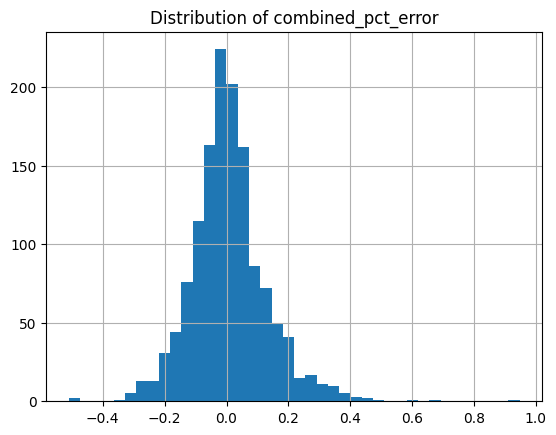

research_expense_pct                       -0.035123
staff_per_student                          -0.031073
equity_ratio                               -0.029533
instructional_staff_long_contract_share    -0.027951
instructional_staff_short_contract_share    0.027951
instruction_expense_pct                     0.027187
placement_services                         -0.019911
irps_fte_per_student                       -0.018555
instructional_staff_short_contract          0.018166
research_share_of_staff                    -0.017926
employment_services                         0.017664
student_service_expense_pct                 0.016639
program_completers                         -0.016503
instructional_fte_per_student              -0.011990
career_counseling                          -0.009805
Name: combined_pct_error, dtype: float64


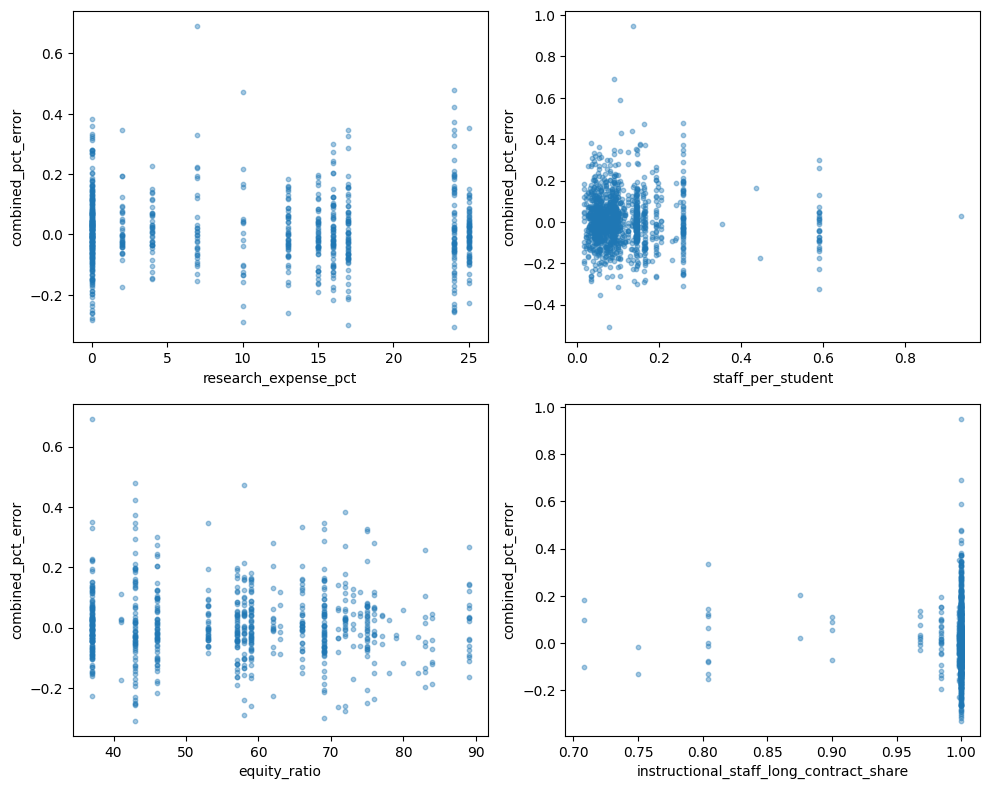

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. How does combined_pct_error actually distribute?
# Is it roughly normal, skewed, bimodal?
inst_model_df['combined_pct_error'].hist(bins=40)
plt.title("Distribution of combined_pct_error")
plt.show()

# 2. Simple correlation screen — what actually correlates with your target?
corr = inst_model_df.drop(columns=['school_name','unit_id'], errors='ignore') \
         .corr()['combined_pct_error'] \
         .drop('combined_pct_error') \
         .sort_values(key=abs, ascending=False)

print(corr.head(15))

# 3. Scatter the top 3-4 correlators against the target
top_features = corr.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(inst_model_df[feat], inst_model_df['combined_pct_error'], alpha=0.4, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('combined_pct_error')
plt.tight_layout()
plt.show()